# Calories Guard — DeepSeek fine-tune

Fine-tune `DeepSeek-R1-Distill-Qwen-1.5B` on a synthetic Thai nutrition Q&A dataset scoped to the Calories Guard app (Thai food calories, macronutrients, diet advice, BMR math). The adapter is then plugged into the backend via the `LOCAL_MODEL_PATH` / `LOCAL_ADAPTER_PATH` env vars and selected with `LLM_PROVIDER=local`.

Pipeline:
1. **Dataset** — ~60 curated Thai Q&A pairs about the app's domain.
2. **Thai word segmentation with an MLP** — since Thai has no spaces, we train a small MLP on character-window features to predict word boundaries. Used as a sanity step before feeding data into the LLM tokenizer. (Educational; the tokenizer ultimately handles subwords itself.)
3. **LoRA fine-tune** — low-rank adapters on the base model so it runs on Colab free tier.
4. **Q↔A alignment visualization** — per epoch, we generate answers on a held-out split and plot the token-overlap percentage between the model's answer and the reference answer, alongside training loss. Straight line up = model is learning the domain; flat line = underfitting.

Run top-to-bottom on a GPU runtime.

## Setup

In [ ]:
# Local: deps already installed (Python 3.13 + CUDA torch 2.6 cu124).
# Colab: uncomment to install pinned versions.
# !pip install -q transformers peft accelerate bitsandbytes datasets pythainlp matplotlib scikit-learn


In [ ]:
import os
import json
import random
from pathlib import Path

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

## 1. App-scoped Thai nutrition Q&A dataset

Hand-curated so every example reflects questions a Calories Guard user would actually ask — Thai food calories, BMR/TDEE, portion sizes, allergy flags, the app's own features. Keep this file version-controlled; re-run fine-tune when it grows.

In [5]:
QA_PAIRS = [
    # ---- Thai main dishes (rice / noodles / curries) ----
    {'q': 'ข้าวผัดกุ้งจานหนึ่งกี่แคลอรี่', 'a': 'ข้าวผัดกุ้ง 1 จาน (ประมาณ 350 กรัม) ให้พลังงานราว 550-650 กิโลแคลอรี่ ขึ้นกับน้ำมันและปริมาณกุ้ง.'},
    {'q': 'ต้มยำกุ้งน้ำใสกี่แคลอรี่', 'a': 'ต้มยำกุ้งน้ำใส 1 ถ้วย (250 กรัม) ประมาณ 90-120 กิโลแคลอรี่ ถ้าเป็นน้ำข้นจะเพิ่มเป็น 250-300.'},
    {'q': 'ผัดไทยกุ้งสดกี่แคล', 'a': 'ผัดไทยกุ้งสด 1 จาน (350 กรัม) ให้พลังงาน 500-600 กิโลแคลอรี่ เพิ่มถั่วลิสงและน้ำมันจะขึ้นอีก.'},
    {'q': 'ส้มตำไทยไม่ใส่ถั่วกี่แคล', 'a': 'ส้มตำไทย 1 จาน (250 กรัม) ไม่ใส่ถั่วลิสง ประมาณ 130-170 กิโลแคลอรี่.'},
    {'q': 'ส้มตำปูปลาร้ากี่แคล', 'a': 'ส้มตำปูปลาร้า 1 จาน (250 กรัม) ประมาณ 150-200 กิโลแคลอรี่ แต่ sodium สูงราว 1,800 มก.'},
    {'q': 'ข้าวเหนียวหมูปิ้ง 2 ไม้ แคลเท่าไหร่', 'a': 'ข้าวเหนียว 1 ห่อ (100 กรัม) ~240 กิโลแคลอรี่ หมูปิ้ง 2 ไม้ ~160 กิโลแคลอรี่ รวม ~400 กิโลแคลอรี่.'},
    {'q': 'ก๋วยเตี๋ยวต้มยำหมูสับกี่แคล', 'a': 'ก๋วยเตี๋ยวต้มยำหมูสับ 1 ชาม (400 กรัม) ประมาณ 380-450 กิโลแคลอรี่.'},
    {'q': 'ก๋วยเตี๋ยวเรือเนื้อกี่แคล', 'a': 'ก๋วยเตี๋ยวเรือเนื้อ 1 ชามเล็ก (250 กรัม) ประมาณ 280-340 กิโลแคลอรี่ น้ำซุปข้นแคลสูงกว่าน้ำใส.'},
    {'q': 'ก๋วยเตี๋ยวเย็นตาโฟกี่แคล', 'a': 'เย็นตาโฟทะเลรวม 1 ชาม (450 กรัม) ประมาณ 400-480 กิโลแคลอรี่ น้ำเย็นตาโฟแดงมีน้ำตาลสูง.'},
    {'q': 'ราดหน้าหมูหมักนุ่มกี่แคล', 'a': 'ราดหน้าหมูหมักนุ่ม 1 จาน (400 กรัม) ประมาณ 550-650 กิโลแคลอรี่ น้ำราดข้นมีแป้งและน้ำมัน.'},
    {'q': 'ผัดซีอิ๊วเส้นใหญ่กี่แคล', 'a': 'ผัดซีอิ๊วเส้นใหญ่หมู 1 จาน (400 กรัม) ประมาณ 550-650 กิโลแคลอรี่ ใส่ไข่เพิ่มอีก ~70.'},
    {'q': 'ขนมจีนน้ำยาปูกี่แคล', 'a': 'ขนมจีนน้ำยาปู 1 จาน (เส้น 200 กรัม + น้ำยา) ประมาณ 480-550 กิโลแคลอรี่.'},
    {'q': 'ข้าวซอยไก่กี่แคล', 'a': 'ข้าวซอยไก่ 1 ชาม (400 กรัม) ประมาณ 600-700 กิโลแคลอรี่ มีกะทิและบะหมี่ทอดเป็นตัวแปรหลัก.'},
    {'q': 'กะเพราหมูสับไข่ดาวกี่แคลอรี่', 'a': 'กะเพราหมูสับราดข้าว 1 จาน + ไข่ดาว 1 ฟอง ประมาณ 600-700 กิโลแคลอรี่.'},
    {'q': 'กะเพราไก่ไม่ใส่ไข่กี่แคล', 'a': 'กะเพราไก่ราดข้าว 1 จาน (350 กรัม) ไม่มีไข่ ประมาณ 500-580 กิโลแคลอรี่.'},
    {'q': 'แกงเขียวหวานไก่กับข้าวกี่แคล', 'a': 'แกงเขียวหวานไก่ 1 ถ้วย (200 กรัม) + ข้าวสวย 1 ถ้วย (150 กรัม) ประมาณ 500-600 กิโลแคลอรี่.'},
    {'q': 'แกงมัสมั่นไก่กี่แคล', 'a': 'แกงมัสมั่นไก่ 1 ถ้วย (250 กรัม) ประมาณ 350-420 กิโลแคลอรี่ กะทิและถั่วลิสงทำให้แคลสูง.'},
    {'q': 'แกงเผ็ดเป็ดย่างกี่แคล', 'a': 'แกงเผ็ดเป็ดย่าง 1 ถ้วย (250 กรัม) ประมาณ 320-400 กิโลแคลอรี่.'},
    {'q': 'แกงส้มกุ้งกี่แคล', 'a': 'แกงส้มกุ้งผักรวม 1 ถ้วย (250 กรัม) ประมาณ 110-150 กิโลแคลอรี่ ไขมันต่ำ.'},
    {'q': 'แกงเลียงกุ้งสดกี่แคล', 'a': 'แกงเลียงกุ้งสด 1 ถ้วย (250 กรัม) ประมาณ 80-110 กิโลแคลอรี่ เป็นแกงแคลต่ำที่สุดของอาหารไทย.'},
    {'q': 'แกงพะแนงเนื้อกี่แคล', 'a': 'แกงพะแนงเนื้อ 1 ถ้วย (200 กรัม) ประมาณ 350-420 กิโลแคลอรี่.'},
    {'q': 'แกงไตปลากี่แคล', 'a': 'แกงไตปลา 1 ถ้วย (250 กรัม) ประมาณ 200-260 กิโลแคลอรี่ sodium สูง.'},
    {'q': 'ต้มข่าไก่กี่แคล', 'a': 'ต้มข่าไก่ 1 ถ้วย (250 กรัม) ประมาณ 200-260 กิโลแคลอรี่ ส่วนใหญ่มาจากกะทิ.'},
    {'q': 'โจ๊กหมูใส่ไข่กี่แคล', 'a': 'โจ๊กหมูใส่ไข่ 1 ชาม (400 กรัม) ประมาณ 280-350 กิโลแคลอรี่.'},
    {'q': 'ข้าวต้มหมูสับกี่แคล', 'a': 'ข้าวต้มหมูสับ 1 ชาม (350 กรัม) ประมาณ 240-300 กิโลแคลอรี่ ใส่ไข่เพิ่ม ~70.'},
    {'q': 'ข้าวมันไก่จานหนึ่งมีกี่แคลอรี่', 'a': 'ข้าวมันไก่ 1 จาน (350 กรัม) ประมาณ 550-650 กิโลแคลอรี่ หนังติดมันจะเพิ่มอีก.'},
    {'q': 'ข้าวมันไก่ทอดกี่แคล', 'a': 'ข้าวมันไก่ทอด 1 จาน (350 กรัม) ประมาณ 700-800 กิโลแคลอรี่ ทอดเพิ่มแคลถึง 150-200.'},
    {'q': 'ข้าวหมูแดงหมูกรอบกี่แคล', 'a': 'ข้าวหมูแดงหมูกรอบ 1 จาน (350 กรัม) ประมาณ 650-750 กิโลแคลอรี่ หมูกรอบมีไขมันสูง.'},
    {'q': 'ข้าวขาหมูกี่แคล', 'a': 'ข้าวขาหมู 1 จาน (350 กรัม) ประมาณ 600-700 กิโลแคลอรี่ หนังขาหมูคือตัวแคลหลัก.'},
    {'q': 'ข้าวคลุกกะปิหมูหวานกี่แคล', 'a': 'ข้าวคลุกกะปิ 1 จาน (350 กรัม) ประมาณ 550-650 กิโลแคลอรี่ หมูหวานเพิ่มน้ำตาลสูง.'},
    {'q': 'ลาบหมูกี่แคล', 'a': 'ลาบหมู 1 จาน (150 กรัม) ประมาณ 200-260 กิโลแคลอรี่ ถ้าใส่ข้าวคั่วเพิ่มอีก 30-50.'},
    {'q': 'น้ำตกเนื้อกี่แคล', 'a': 'น้ำตกเนื้อ 1 จาน (150 กรัม) ประมาณ 230-280 กิโลแคลอรี่.'},
    {'q': 'ยำวุ้นเส้นทะเลกี่แคล', 'a': 'ยำวุ้นเส้นทะเล 1 จาน (300 กรัม) ประมาณ 250-310 กิโลแคลอรี่ น้ำตาลในน้ำยำคือตัวแปร.'},
    {'q': 'ยำมาม่ากี่แคล', 'a': 'ยำมาม่า 1 จาน (300 กรัม) ประมาณ 380-450 กิโลแคลอรี่ sodium สูงจากผงมาม่า.'},
    {'q': 'ไข่เจียวหมูสับกี่แคลอรี่', 'a': 'ไข่เจียวหมูสับใช้ไข่ 2 ฟอง + หมูสับ 50 กรัม ทอดในน้ำมัน ประมาณ 350-420 กิโลแคลอรี่.'},
    {'q': 'ข้าวไข่เจียวกี่แคล', 'a': 'ข้าวไข่เจียว (ไข่ 2 ฟอง + ข้าว 1 จาน) ประมาณ 450-520 กิโลแคลอรี่.'},
    {'q': 'ข้าวไข่ข้นกุ้งกี่แคล', 'a': 'ข้าวไข่ข้นกุ้ง 1 จาน (350 กรัม) ประมาณ 600-700 กิโลแคลอรี่ เพราะใส่เนยและครีม.'},
    {'q': 'หมูทอดกระเทียมกี่แคล', 'a': 'หมูทอดกระเทียม 1 จาน (200 กรัม) ประมาณ 400-480 กิโลแคลอรี่.'},
    {'q': 'ปลาทอดน้ำปลากี่แคล', 'a': 'ปลานิลทอดน้ำปลา 1 ตัว (200 กรัม) ประมาณ 350-420 กิโลแคลอรี่ ถ้าทอดในน้ำมันท่วม.'},
    {'q': 'ผัดผักรวมมิตรกี่แคล', 'a': 'ผัดผักรวมมิตร 1 จาน (250 กรัม) ประมาณ 130-180 กิโลแคลอรี่ ขึ้นกับน้ำมัน.'},
    {'q': 'หมูสามชั้นย่างกี่แคล', 'a': 'หมูสามชั้นย่าง 1 จาน (150 กรัม) ประมาณ 450-550 กิโลแคลอรี่ ไขมันอิ่มตัวสูง.'},
    {'q': 'คอหมูย่างกี่แคล', 'a': 'คอหมูย่าง 1 จาน (150 กรัม) ประมาณ 350-420 กิโลแคลอรี่.'},
    {'q': 'ปลาหมึกย่างกี่แคล', 'a': 'ปลาหมึกย่าง 1 ตัวกลาง (150 กรัม) ประมาณ 130-160 กิโลแคลอรี่ โปรตีนสูง 25-30 กรัม.'},
    {'q': 'กุ้งเผาตัวกลางกี่แคล', 'a': 'กุ้งแม่น้ำเผา 1 ตัว (150 กรัม) ประมาณ 130-160 กิโลแคลอรี่ ไม่รวมมันกุ้ง.'},
    {'q': 'ปูนึ่งกี่แคล', 'a': 'ปูม้านึ่ง 1 ตัวกลาง (200 กรัม เนื้อ 80 กรัม) ประมาณ 80-100 กิโลแคลอรี่ โปรตีน 18 กรัม.'},
    {'q': 'หอยแมลงภู่นึ่งกี่แคล', 'a': 'หอยแมลงภู่นึ่ง 1 จาน (200 กรัม เนื้อ) ประมาณ 150-180 กิโลแคลอรี่ โปรตีนสูงไขมันต่ำ.'},
    # ---- Snacks / desserts / beverages ----
    {'q': 'โรตีชีสกี่แคล', 'a': 'โรตีชีส 1 แผ่น (150 กรัม) ประมาณ 380-450 กิโลแคลอรี่ ขึ้นกับปริมาณน้ำตาลและนม.'},
    {'q': 'โรตีกล้วยไข่กี่แคล', 'a': 'โรตีกล้วยไข่นมข้น 1 แผ่น (180 กรัม) ประมาณ 400-500 กิโลแคลอรี่.'},
    {'q': 'ขนมครก 5 ฝากี่แคล', 'a': 'ขนมครก 5 ฝา (~70 กรัม) ประมาณ 180-220 กิโลแคลอรี่ ส่วนใหญ่เป็นกะทิและน้ำตาล.'},
    {'q': 'บัวลอยน้ำกะทิกี่แคล', 'a': 'บัวลอยน้ำกะทิ 1 ถ้วย (200 กรัม) ประมาณ 280-340 กิโลแคลอรี่.'},
    {'q': 'ข้าวเหนียวมะม่วงกี่แคล', 'a': 'ข้าวเหนียวมะม่วง (ข้าว 100 กรัม + มะม่วงครึ่งลูก + กะทิ) ประมาณ 380-450 กิโลแคลอรี่.'},
    {'q': 'ทับทิมกรอบน้ำกะทิกี่แคล', 'a': 'ทับทิมกรอบ 1 ถ้วย (200 กรัม) ประมาณ 250-310 กิโลแคลอรี่ น้ำตาลสูง.'},
    {'q': 'ขนมเปียกปูนกะทิ 1 ชิ้นกี่แคล', 'a': 'ขนมเปียกปูนกะทิ 1 ชิ้น (60 กรัม) ประมาณ 130-160 กิโลแคลอรี่.'},
    {'q': 'ทองหยิบฝอยทอง 1 คำกี่แคล', 'a': 'ทองหยิบ 1 ดอก (10 กรัม) ~35 กิโลแคลอรี่, ฝอยทอง 30 กรัม ~95 กิโลแคลอรี่ น้ำตาลสูงมาก.'},
    {'q': 'ชานมไข่มุกแก้วเดียวกี่แคล', 'a': 'ชานมไข่มุก 1 แก้ว (500 มล.) ประมาณ 300-500 กิโลแคลอรี่ ไข่มุกและน้ำตาลคือตัวแปรหลัก.'},
    {'q': 'ชานมไข่มุกหวาน 0% กี่แคล', 'a': 'ชานมไข่มุกหวาน 0% 1 แก้ว (500 มล.) ประมาณ 200-260 กิโลแคลอรี่ ไข่มุกยังให้แคล 100+.'},
    {'q': 'กาแฟเย็นหวานน้อยกี่แคล', 'a': 'กาแฟเย็นหวานน้อย 1 แก้ว (400 มล.) ประมาณ 150-200 กิโลแคลอรี่.'},
    {'q': 'กาแฟดำไม่ใส่น้ำตาลกี่แคล', 'a': 'กาแฟดำไม่ใส่น้ำตาลและนม 1 แก้ว (250 มล.) ประมาณ 2-5 กิโลแคลอรี่.'},
    {'q': 'น้ำมะพร้าวแก้วเดียวกี่แคล', 'a': 'น้ำมะพร้าวสด 1 ลูก (300 มล.) ประมาณ 60-80 กิโลแคลอรี่ ไม่รวมเนื้อ.'},
    {'q': 'น้ำส้มคั้นแก้วกี่แคล', 'a': 'น้ำส้มคั้น 250 มล. ประมาณ 110-130 กิโลแคลอรี่ น้ำตาลธรรมชาติ ~25 กรัม.'},
    {'q': 'นมถั่วเหลืองหวานน้อยกี่แคล', 'a': 'นมถั่วเหลืองหวานน้อย 250 มล. ประมาณ 90-120 กิโลแคลอรี่ โปรตีน 7-9 กรัม.'},
    {'q': 'นมวัวสด 250 มล. กี่แคล', 'a': 'นมวัวสดไขมันเต็ม 250 มล. ประมาณ 150-160 กิโลแคลอรี่ ถ้าไขมันต่ำ ~100.'},
    {'q': 'น้ำเปล่าแก้วใหญ่กี่แคล', 'a': 'น้ำเปล่า 1 แก้ว (250 มล.) มี 0 กิโลแคลอรี่ ไม่ส่งผลต่อสมดุลพลังงาน แต่ช่วยรู้สึกอิ่ม.'},
    # ---- Fruits / single ingredients ----
    {'q': 'แอปเปิ้ลลูกกลางมีกี่แคล', 'a': 'แอปเปิ้ลลูกกลาง (~180 กรัม) ประมาณ 90-100 กิโลแคลอรี่ มีใยอาหาร 4 กรัม.'},
    {'q': 'กล้วยหอม 1 ลูกกี่แคล', 'a': 'กล้วยหอม 1 ลูก (~120 กรัม) ประมาณ 105-115 กิโลแคลอรี่ มีโพแทสเซียมสูง.'},
    {'q': 'กล้วยน้ำว้า 1 ลูกกี่แคล', 'a': 'กล้วยน้ำว้าสุก 1 ลูก (~70 กรัม) ประมาณ 60-70 กิโลแคลอรี่.'},
    {'q': 'มะม่วงสุก 1 ลูกกี่แคล', 'a': 'มะม่วงน้ำดอกไม้สุก 1 ลูก (~250 กรัม เนื้อ 200 กรัม) ประมาณ 130-160 กิโลแคลอรี่.'},
    {'q': 'มะละกอสุก 1 จานกี่แคล', 'a': 'มะละกอสุก 1 จาน (200 กรัม) ประมาณ 80-100 กิโลแคลอรี่ มีวิตามินซีสูง.'},
    {'q': 'องุ่นแดง 100 กรัมกี่แคล', 'a': 'องุ่น 100 กรัม ประมาณ 65-75 กิโลแคลอรี่ น้ำตาลธรรมชาติ 16-18 กรัม.'},
    {'q': 'แตงโม 100 กรัมกี่แคล', 'a': 'แตงโม 100 กรัม ประมาณ 30-35 กิโลแคลอรี่ น้ำเยอะ ดีสำหรับไดเอท.'},
    {'q': 'สับปะรด 100 กรัมกี่แคล', 'a': 'สับปะรด 100 กรัม ประมาณ 50-55 กิโลแคลอรี่ มีเอนไซม์ bromelain ช่วยย่อยโปรตีน.'},
    {'q': 'อะโวคาโดครึ่งลูกกี่แคล', 'a': 'อะโวคาโดครึ่งลูก (~100 กรัม) ประมาณ 160-170 กิโลแคลอรี่ ไขมันดี (monounsaturated) สูง.'},
    {'q': 'ทุเรียนหมอนทอง 1 ก้อนกี่แคล', 'a': 'ทุเรียนหมอนทอง 1 พู (เนื้อ 100 กรัม) ประมาณ 145-180 กิโลแคลอรี่ คาร์บและไขมันสูง.'},
    {'q': 'ข้าวกล่องอกไก่ต้มมีโปรตีนกี่กรัม', 'a': 'อกไก่ต้ม 150 กรัม มีโปรตีนประมาณ 35-40 กรัม ไขมันต่ำประมาณ 3 กรัม.'},
    {'q': 'ไข่ต้ม 1 ฟองมีโปรตีนกี่กรัม', 'a': 'ไข่ไก่ต้ม 1 ฟอง (50 กรัม) มีโปรตีน 6-7 กรัม ไขมัน 5 กรัม ~70 กิโลแคลอรี่.'},
    {'q': 'ไข่ขาว 100 กรัมกี่แคล', 'a': 'ไข่ขาว 100 กรัม ประมาณ 50-55 กิโลแคลอรี่ มีโปรตีน 11 กรัม ไขมัน 0 กรัม.'},
    {'q': 'ปลาทูนึ่ง 1 ตัวกี่แคล', 'a': 'ปลาทูนึ่ง 1 ตัว (80 กรัม) ประมาณ 130-160 กิโลแคลอรี่ โปรตีน 18-20 กรัม โอเมก้า-3 สูง.'},
    {'q': 'อกไก่ดิบ 100 กรัมกี่แคล', 'a': 'อกไก่ดิบไม่มีหนัง 100 กรัม ประมาณ 110-120 กิโลแคลอรี่ โปรตีน 23 กรัม.'},
    {'q': 'ข้าวสวย 1 ทัพพีกี่แคล', 'a': 'ข้าวสวย 1 ทัพพี (~60 กรัม) ประมาณ 75-85 กิโลแคลอรี่.'},
    {'q': 'ข้าวกล้อง 1 ถ้วยกี่แคล', 'a': 'ข้าวกล้อง 1 ถ้วย (150 กรัม) ประมาณ 170-200 กิโลแคลอรี่ มีใยอาหารสูงกว่าข้าวขาว.'},
    {'q': 'ขนมปังโฮลวีต 1 แผ่นกี่แคล', 'a': 'ขนมปังโฮลวีต 1 แผ่น (30 กรัม) ประมาณ 70-90 กิโลแคลอรี่ ไฟเบอร์ 2-3 กรัม.'},
    {'q': 'มันหวานญี่ปุ่นต้ม 100 กรัมกี่แคล', 'a': 'มันหวานญี่ปุ่นต้ม 100 กรัม ประมาณ 85-95 กิโลแคลอรี่ ไฟเบอร์สูง.'},
    {'q': 'อกไก่ย่าง 100 กรัมโปรตีนกี่กรัม', 'a': 'อกไก่ย่าง 100 กรัม โปรตีน 30-32 กรัม ไขมัน 3-4 กรัม ~165 กิโลแคลอรี่.'},
    {'q': 'แซลมอน 100 กรัมกี่แคล', 'a': 'แซลมอนสด 100 กรัม ประมาณ 200-220 กิโลแคลอรี่ โอเมก้า-3 ~2 กรัม.'},
    # ---- Sweets / fast food ----
    {'q': 'ไก่ทอด KFC ชิ้นใหญ่กี่แคล', 'a': 'ไก่ทอด KFC 1 ชิ้นใหญ่ (~150 กรัม) ประมาณ 380-450 กิโลแคลอรี่ sodium 1,200 มก.'},
    {'q': 'แมคโดนัลด์บิ๊กแมคกี่แคล', 'a': 'Big Mac 1 ชิ้น (215 กรัม) ประมาณ 540-580 กิโลแคลอรี่ ไขมัน 28 กรัม.'},
    {'q': 'พิซซ่าฮัทหน้าฮาวายเอี้ยน 1 ชิ้นกี่แคล', 'a': 'พิซซ่าฮัทขอบหนาฮาวายเอี้ยน 1 ชิ้น (~100 กรัม) ประมาณ 230-270 กิโลแคลอรี่.'},
    {'q': 'เฟรนช์ฟรายส์ขนาดกลางกี่แคล', 'a': 'เฟรนช์ฟรายส์ขนาดกลาง (~115 กรัม) ประมาณ 320-360 กิโลแคลอรี่ ไขมัน 16 กรัม.'},
    {'q': 'โดนัทกลมหวาน 1 ชิ้นกี่แคล', 'a': 'โดนัทกลมเคลือบน้ำตาล 1 ชิ้น (60 กรัม) ประมาณ 250-280 กิโลแคลอรี่.'},
    {'q': 'ครัวซองต์เนยกี่แคล', 'a': 'ครัวซองต์เนยล้วน 1 ชิ้น (60 กรัม) ประมาณ 230-270 กิโลแคลอรี่ ไขมัน 12 กรัม.'},
    {'q': 'พายไก่กี่แคล', 'a': 'พายไก่ 1 ชิ้น (140 กรัม) ประมาณ 380-450 กิโลแคลอรี่.'},
    {'q': 'ฮอทดอกไส้กรอกกี่แคล', 'a': 'ฮอทดอกไส้กรอกกับขนมปัง 1 ชิ้น (~100 กรัม) ประมาณ 280-340 กิโลแคลอรี่.'},
    {'q': 'มาม่ารสต้มยำ 1 ซองกี่แคล', 'a': 'มาม่าต้มยำ 1 ซอง (60 กรัม) ประมาณ 300-340 กิโลแคลอรี่ sodium 1,500 มก.'},
    # ---- Macro / nutrition science ----
    {'q': 'BMR คืออะไร คำนวณยังไง', 'a': 'BMR คือพลังงานที่ร่างกายใช้ขณะพัก สูตร Mifflin-St Jeor ผู้ชาย: 10×น้ำหนัก + 6.25×ส่วนสูง - 5×อายุ + 5, ผู้หญิงลบ 161 แทนบวก 5.'},
    {'q': 'TDEE ต่างจาก BMR ยังไง', 'a': 'TDEE = BMR × ค่ากิจกรรม (1.2 ไม่ออกกำลัง, 1.375 เบา, 1.55 ปานกลาง, 1.725 หนัก). เป็นแคลอรี่ที่ร่างกายต้องใช้จริงต่อวัน.'},
    {'q': 'อยากลดน้ำหนัก 1 กิโลต่อสัปดาห์ ต้องลดแคลวันละเท่าไหร่', 'a': 'ไขมัน 1 กิโลกรัม ≈ 7,700 กิโลแคลอรี่ ต้องขาดดุลพลังงานประมาณ 1,100 กิโลแคลอรี่ต่อวันในการลด 1 กก./สัปดาห์ ซึ่งเร็วเกินไปและยากยั่งยืน แนะนำ 0.5 กก./สัปดาห์ (ขาดดุล 550 kcal/วัน).'},
    {'q': 'กินคาร์บน้อยคืนละเท่าไหร่ถึงจะดี', 'a': 'สำหรับคีโต คาร์บสุทธิ < 50 กรัม/วัน, โลว์คาร์บทั่วไป 50-130 กรัม/วัน, ไม่แนะนำต่ำกว่า 20 กรัม/วันโดยไม่ปรึกษาแพทย์.'},
    {'q': 'โปรตีนวันละเท่าไหร่สำหรับคนออกกำลังกาย', 'a': 'คนทั่วไป 0.8 ก./กก. ออกกำลังกายคาร์ดิโอ 1.2-1.4 ก./กก. เวทเทรนนิ่งเพิ่มกล้าม 1.6-2.2 ก./กก.'},
    {'q': 'ไขมันอิ่มตัวกับไขมันไม่อิ่มตัวต่างกันยังไง', 'a': 'ไขมันอิ่มตัว (เนย, มันสัตว์) เป็นของแข็งที่อุณหภูมิห้องและเพิ่ม LDL. ไขมันไม่อิ่มตัว (น้ำมันมะกอก, ถั่ว, ปลา) ช่วยลด LDL ควรจำกัดไขมันอิ่มตัว < 10% ของแคลอรี่ทั้งวัน.'},
    {'q': 'กินไฟเบอร์วันละเท่าไหร่', 'a': 'ผู้ใหญ่ควรได้ไฟเบอร์ 25-38 กรัม/วัน ส่วนใหญ่จากผัก ผลไม้ ธัญพืชไม่ขัดสี ช่วยขับถ่ายและควบคุมน้ำตาล.'},
    {'q': 'ดื่มน้ำเปล่าวันละกี่ลิตรดี', 'a': 'ผู้ใหญ่ 2-2.5 ลิตรต่อวัน หรือ 30-35 มล./กก.น้ำหนักตัว เพิ่มขึ้นเมื่ออากาศร้อนหรือออกกำลังกาย.'},
    {'q': 'น้ำตาลวันละเท่าไหร่ไม่เกินดี', 'a': 'WHO แนะนำน้ำตาลเติมไม่เกิน 10% ของแคลอรี่รวม เหมาะสมยิ่งกว่าคือ < 5% (ผู้หญิง ~25 กรัม/วัน, ผู้ชาย ~36 กรัม/วัน).'},
    {'q': 'sodium วันละไม่เกินเท่าไหร่', 'a': 'WHO แนะนำ sodium ไม่เกิน 2,000 มก./วัน (เท่าเกลือ ~5 กรัม). คนไทยเฉลี่ยกินเกินถึง 4,000 มก. เพราะน้ำปลา ผงชูรส.'},
    {'q': 'แคลเซียมวันละเท่าไหร่', 'a': 'ผู้ใหญ่ 1,000 มก./วัน (>50 ปีหญิง 1,200 มก.) จากนม โยเกิร์ต ปลาเล็กปลาน้อย ผักใบเขียว.'},
    {'q': 'วิตามิน D ขาดง่ายไหมในไทย', 'a': 'แม้แดดแรง คนไทยเมืองมักขาด vitamin D เพราะอยู่ในออฟฟิศและทาครีมกันแดด แนะนำ 600-800 IU/วัน.'},
    {'q': 'ค่า GI คืออะไร', 'a': 'Glycemic Index วัดว่าคาร์บทำให้น้ำตาลในเลือดขึ้นเร็วแค่ไหน. GI สูง > 70 (น้ำตาล, ขนมปังขาว), ปานกลาง 56-69, ต่ำ < 55 (ข้าวกล้อง, ถั่ว, ผัก).'},
    {'q': 'แคลอรี่หนึ่งกรัมของโปรตีนไขมันคาร์บเท่าไหร่', 'a': 'โปรตีน 4 kcal/กรัม, คาร์บ 4 kcal/กรัม, ไขมัน 9 kcal/กรัม, แอลกอฮอล์ 7 kcal/กรัม.'},
    {'q': 'EPOC คืออะไร', 'a': 'Excess Post-exercise Oxygen Consumption คือพลังงานที่ร่างกายเผาผลาญเพิ่มหลังออกกำลังกายหนัก เพื่อฟื้นฟูร่างกาย เผาผลาญเพิ่มได้ 6-15% ของแคลที่ใช้ตอนออก.'},
    # ---- Exercise / cardio ----
    {'q': 'วิ่งเผาผลาญกี่แคลต่อชั่วโมง', 'a': 'วิ่ง 8 กม./ชม. (6:45 min/km) เผาผลาญ 500-650 กิโลแคลอรี่/ชั่วโมง ขึ้นกับน้ำหนักตัว. 60 กก. ≈ 540 kcal.'},
    {'q': 'เดินเร็ว 30 นาทีเผาผลาญเท่าไหร่', 'a': 'เดินเร็ว 6 กม./ชม. เผาผลาญ ~4 MET × 60 กก. × 0.5 ชม. ≈ 120 กิโลแคลอรี่.'},
    {'q': 'ว่ายน้ำ 45 นาทีเผาผลาญเท่าไหร่', 'a': 'ว่ายน้ำฟรีสไตล์ระดับกลาง ~8 MET × 60 กก. × 0.75 ชม. ≈ 360 กิโลแคลอรี่.'},
    {'q': 'ยกน้ำหนัก 1 ชั่วโมงเผาผลาญกี่แคล', 'a': 'เวทเทรนนิ่งหนักปานกลาง ~6 MET × 60 กก. × 1 ชม. ≈ 360 กิโลแคลอรี่ และยังเพิ่ม EPOC หลังออกกำลัง.'},
    {'q': 'ปั่นจักรยานช้า 1 ชั่วโมงเผาผลาญเท่าไหร่', 'a': 'ปั่นจักรยานเรื่อย ๆ 16 กม./ชม. ~6 MET × 60 กก. × 1 ชม. ≈ 360 กิโลแคลอรี่.'},
    {'q': 'โยคะ 60 นาทีเผาผลาญเท่าไหร่', 'a': 'โยคะระดับ Hatha ~3 MET × 60 กก. × 1 ชม. ≈ 180 กิโลแคลอรี่. Power yoga จะเพิ่มเป็น ~300-360 kcal.'},
    {'q': 'HIIT 20 นาทีเผาผลาญเท่าไหร่', 'a': 'HIIT 20 นาที ~10-12 MET เฉลี่ย × 60 กก. × 0.33 ชม. ≈ 200-240 กิโลแคลอรี่ + EPOC อีก 30-50.'},
    {'q': 'กระโดดเชือก 15 นาทีเผาผลาญเท่าไหร่', 'a': 'กระโดดเชือก ~12 MET × 60 กก. × 0.25 ชม. ≈ 180 กิโลแคลอรี่.'},
    {'q': 'ขึ้นบันได 10 นาทีเผาผลาญกี่แคล', 'a': 'ขึ้นบันไดต่อเนื่อง ~8 MET × 60 กก. × 0.17 ชม. ≈ 80 กิโลแคลอรี่.'},
    {'q': 'เดิน 10,000 ก้าวเผาผลาญกี่แคล', 'a': '10,000 ก้าว (~7-8 กม.) เผาผลาญประมาณ 300-450 กิโลแคลอรี่ ขึ้นกับความเร็วและน้ำหนัก.'},
    # ---- Diet patterns / advice ----
    {'q': 'อาหารคลีนคืออะไร', 'a': 'อาหารคลีนคืออาหารที่ผ่านการแปรรูปน้อย ไม่ใส่ผงชูรส/น้ำตาลเติม ไม่ทอดในน้ำมันเยอะ เน้นผัก ผลไม้ ธัญพืชไม่ขัดสี และโปรตีนคุณภาพดี.'},
    {'q': 'Intermittent Fasting 16/8 คืออะไร', 'a': 'IF 16/8 = อดอาหาร 16 ชั่วโมง กินในช่วง 8 ชั่วโมง (เช่น 12:00-20:00). ช่วยควบคุมแคลอรี่และอินซูลิน เหมาะกับคนที่ไม่หิวเช้า.'},
    {'q': 'คาร์ดิโอหรือเวทดีกว่ากันสำหรับลดไขมัน', 'a': 'ทั้งสองจำเป็น: คาร์ดิโอเผาผลาญเยอะต่อครั้ง, เวทเพิ่มมวลกล้ามเนื้อทำให้ BMR สูงขึ้น. แนะนำคาร์ดิโอ 3 วัน + เวท 2 วัน/สัปดาห์.'},
    {'q': 'กินไก่ทอดแล้วน้ำหนักขึ้นเร็วไหม', 'a': 'ไก่ทอด 1 ชิ้น (120 กรัม) ~300-380 กิโลแคลอรี่ มีไขมันอิ่มตัวสูง กินบ่อยเกินจะเพิ่มน้ำหนักและ LDL แนะนำไม่เกิน 1 ครั้ง/สัปดาห์.'},
    {'q': 'กินอิ่มแล้วยังหิว ทำยังไง', 'a': 'เพิ่มโปรตีนและไฟเบอร์ในมื้อ, ดื่มน้ำก่อนกิน, นอนให้พอ, ตรวจว่ากินแคลอรี่รวมต่ำเกินไปไหม (ต่ำกว่า BMR ทำให้หิวตลอด).'},
    {'q': 'อาหารว่างกลางคืนแคลต่ำแนะนำอะไร', 'a': 'โยเกิร์ตกรีกไม่หวาน 100 กรัม (~60 kcal), แอปเปิ้ลครึ่งลูก (~50 kcal), ไข่ต้ม 1 ฟอง (~70 kcal), ถั่วเอดามาเม่ 50 กรัม (~60 kcal).'},
    {'q': 'อาหารแคลต่ำอิ่มท้องมีอะไรบ้าง', 'a': 'ผักใบเขียวต้มจืด, ซุปใส, ไข่ขาว, อกไก่ต้ม, แตงกวา, บรอกโคลี, แอปเปิ้ล — กินแล้วอิ่มเพราะน้ำและไฟเบอร์สูง แต่แคลต่ำ.'},
    {'q': 'ผลไม้ชนิดไหนน้ำตาลต่ำ', 'a': 'ผลไม้น้ำตาลต่ำ: สตรอว์เบอร์รี่, บลูเบอร์รี่, ฝรั่ง, แอปเปิ้ลเขียว, แคนตาลูป, แตงโม. หลีกเลี่ยงองุ่น, มะม่วงสุก, ลำไย.'},
    {'q': 'อาหารในตู้เย็นมีแค่ไข่กับผัก จะทำอะไรแคลต่ำได้', 'a': 'ไข่เจียวผัก 2 ฟอง (~250 kcal) หรือไข่ต้มคู่สลัดผัก (~160 kcal) หรือผักลวกจิ้มน้ำจิ้ม + ไข่ต้ม (~180 kcal) เป็นตัวเลือกแคลต่ำโปรตีนสูง.'},
    {'q': 'กินข้าวเย็นตอน 21:00 น้ำหนักขึ้นไหม', 'a': 'ไม่ใช่เวลาที่เป็นปัญหาหลัก แต่คือแคลรวมทั้งวัน. ถ้าแคลไม่เกิน TDEE และกินก่อนนอนอย่างน้อย 2 ชั่วโมง (เพื่อไม่กรดไหลย้อน) ก็ไม่ทำให้อ้วนโดยตรง.'},
    {'q': 'หมาลาสูง sodium ไหม', 'a': 'หมาล่าเผ็ดหม่า 1 จาน (500 กรัม) มี sodium ประมาณ 2,500-3,500 มิลลิกรัม เกินขีดจำกัดวันละ 2,000 มก. ของ WHO แนะนำกินนาน ๆ ครั้ง.'},
    {'q': 'ถ้าเพิ่งกินชานมไข่มุกไป ต้องออกกำลังกายกี่นาที', 'a': 'ชานมไข่มุก 1 แก้ว 400 กิโลแคลอรี่ ต้องวิ่งระดับกลาง ~50 นาที หรือเดินเร็ว 100+ นาทีจึงเผาผลาญหมด.'},
    {'q': 'แพ้กลูเตนกินข้าวเจ้าได้ไหม', 'a': 'ข้าวเจ้าและข้าวเหนียวไม่มีกลูเตน กินได้. ควรเลี่ยง: ข้าวสาลี, บาร์เลย์, โอ๊ต (ยกเว้นติดฉลาก gluten-free), บะหมี่, ขนมปัง.'},
    {'q': 'แพ้นมวัวกินอะไรแทนได้', 'a': 'แทนนมวัวด้วย: นมถั่วเหลืองเสริมแคลเซียม, นมอัลมอนด์ไม่หวาน, นมข้าวโอ๊ต, นมมะพร้าว. ดู ingredient ว่าเสริมแคลเซียมและ vitamin D หรือเปล่า.'},
    {'q': 'แพ้กุ้งกินซีอิ๊วได้ไหม', 'a': 'แพ้กุ้งคือแพ้สัตว์เปลือกแข็ง ไม่เกี่ยวกับซีอิ๊ว (ทำจากถั่วเหลือง+ข้าวสาลี). กินซีอิ๊วได้ปกติ ยกเว้นแพ้ถั่วเหลืองหรือกลูเตน.'},
    {'q': 'แพ้ถั่วลิสงกินถั่วอื่นได้ไหม', 'a': 'แพ้ถั่วลิสงไม่จำเป็นต้องแพ้ถั่วเปลือกแข็ง (อัลมอนด์, วอลนัท) แต่บางคนแพ้ทั้งคู่ ควรปรึกษาแพทย์ทดสอบเฉพาะ และอ่านฉลากระวัง cross-contamination.'},
    {'q': 'ไดเอทคีโตทำได้นานแค่ไหน', 'a': 'คีโตปลอดภัยถ้าทำถูก สามารถทำได้ 3-6 เดือน แล้วสลับช่วง maintain. ระยะยาว > 1 ปีอาจกระทบไต ตับ และระดับ cholesterol แนะนำตรวจเลือดเป็นระยะ.'},
    # ---- App-specific Q&A ----
    {'q': 'แอปนี้คำนวณ BMR ยังไง', 'a': 'แอป Calories Guard ใช้สูตร Mifflin-St Jeor โดยต้องการข้อมูล เพศ อายุ ส่วนสูง น้ำหนัก ซึ่งกรอกตอนสมัครสมาชิกหรือแก้ไขที่หน้าโปรไฟล์.'},
    {'q': 'แอปเชื่อมกับ Samsung Health ได้ไหม', 'a': 'ได้ ผ่าน Health Connect บน Android — ไปที่หน้าบันทึกแคลอรี่ กดปุ่มซิงค์ Samsung Health แอปจะดึงแคลอรี่ที่เผาผลาญและจำนวนก้าวของวันนั้นมาอัตโนมัติ.'},
    {'q': 'แอปเชื่อมกับ Apple Health ได้ไหม', 'a': 'แอป Calories Guard ปัจจุบันรองรับ Health Connect ของ Android เป็นหลัก. ฝั่ง iOS ยังไม่ได้ wire HealthKit ตรง ๆ จะอยู่ใน roadmap.'},
    {'q': 'ลบข้อมูลบัญชีในแอปทำยังไง', 'a': 'ไปที่หน้าโปรไฟล์ → ตั้งค่า → ลบบัญชี ข้อมูลทั้งหมดจะถูก soft-delete ทันทีและถูกลบถาวรใน 30 วัน ตามนโยบาย PDPA.'},
    {'q': 'AI ในแอปบอกแคลผิด ทำยังไง', 'a': 'ถ้าประมาณแคลไม่ตรง ให้กดแก้ไขที่รายการอาหารแล้วพิมพ์แคลจริง ระบบจะใช้ค่าที่แก้ไข และทีมแอดมินจะทบทวนเมนูให้แม่นขึ้นในรอบถัดไป.'},
    {'q': 'ทำไมไม่เห็นข้อมูลจาก Samsung Health', 'a': 'ตรวจสอบ: (1) ติดตั้ง Health Connect แล้ว (2) เปิดสิทธิ์ Samsung Health → Health Connect → อนุญาตทั้งหมด (3) มีกิจกรรมที่ Samsung Health บันทึกไว้จริงในวันนี้.'},
    {'q': 'ทำไมแอปไม่นับเนื้อสัตว์ดิบ', 'a': 'เนื้อดิบกับเนื้อปรุงสุกมีแคลต่างกันเพราะน้ำในเนื้อระเหย ระบบเก็บค่าเฉพาะเมนูที่ปรุงสุกเพื่อความแม่นยำในการคำนวณจริง.'},
    {'q': 'แอปใช้ AI อะไร', 'a': 'Calories Guard ใช้ LLM สำหรับประมาณแคลอรี่จากข้อความ ค้นหาเมนู และสร้างสูตรอาหารอัตโนมัติ รองรับ Gemini, DeepSeek และโมเดล open-source ที่ fine-tune เอง ผ่าน abstraction ในไฟล์ llm_provider.py.'},
    {'q': 'ตั้งเป้าน้ำหนักในแอปยังไง', 'a': 'ไปที่หน้าโปรไฟล์ → ตั้งเป้าหมาย → กรอกน้ำหนักเป้าหมายและกรอบเวลา ระบบคำนวณแคลที่ควรกินต่อวันและแสดงในหน้าหลัก.'},
    {'q': 'แอปแจ้งเตือนน้ำได้ไหม', 'a': 'ได้ ในหน้าตั้งค่า → การแจ้งเตือนน้ำ — ตั้งช่วงเวลาและจำนวนแก้ว/วัน แอปจะส่ง local notification เตือนทุกชั่วโมงในช่วงที่ตั้ง.'},
    {'q': 'แอปบันทึกน้ำหนักความถี่เท่าไหร่', 'a': 'แนะนำชั่งทุก 1-2 สัปดาห์ในเวลาเดียวกัน (เช่นเช้าหลังเข้าห้องน้ำ). แอปเตือนชั่งน้ำหนักทุก 14 วันโดยอัตโนมัติผ่าน lifecycle service.'},
    {'q': 'อยากดูรีวิวเมนูจากผู้ใช้คนอื่น', 'a': 'แตะเมนูที่ค้นหา → เลื่อนลงไปด้านล่าง → ดูรีวิว/คะแนนของผู้ใช้คนอื่น และสามารถกดให้คะแนน 1-5 ดาวพร้อมเขียนรีวิวเองได้.'},
    {'q': 'แอปแชร์ progress ให้เพื่อนได้ไหม', 'a': 'ในหน้า Progress → กดปุ่มแชร์ ระบบ generate รูปภาพสรุปกราฟน้ำหนัก/แคลแล้วเปิด share sheet ให้เลือก app ปลายทาง (Line, IG, Facebook).'},
    {'q': 'admin ในแอปทำอะไรได้บ้าง', 'a': 'admin จัดการเมนูอาหาร (เพิ่ม/แก้ไข/ลบ), ตอบคำขอเพิ่มเมนูจากผู้ใช้ผ่านหน้า approve, และดู dashboard สรุปจำนวนผู้ใช้/บันทึกในแต่ละช่วง.'},
    {'q': 'ใส่สูตรอาหารเองได้ไหม', 'a': 'ได้ ในหน้าค้นหาเมนู → ปุ่ม + → กรอกชื่อสูตร, วัตถุดิบ, แคล/มาโครต่อหนึ่งหน่วยบริโภค ระบบจะส่งให้ admin ตรวจก่อน publish.'},
]

print(f'Dataset: {len(QA_PAIRS)} Q&A pairs')

# Persist 70/15/15 split so re-runs reuse the same split (avoids leakage between runs).
DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)
TRAIN_FILE, VAL_FILE, TEST_FILE = DATA_DIR / 'train.json', DATA_DIR / 'val.json', DATA_DIR / 'test.json'

if TRAIN_FILE.exists() and VAL_FILE.exists() and TEST_FILE.exists():
    TRAIN_QA = json.loads(TRAIN_FILE.read_text(encoding='utf-8'))
    VAL_QA   = json.loads(VAL_FILE.read_text(encoding='utf-8'))
    TEST_QA  = json.loads(TEST_FILE.read_text(encoding='utf-8'))
    print('Loaded persisted split.')
else:
    rng = random.Random(SEED)
    pool = QA_PAIRS.copy()
    rng.shuffle(pool)
    n = len(pool)
    n_train = int(0.70 * n)
    n_val = int(0.15 * n)
    TRAIN_QA = pool[:n_train]
    VAL_QA   = pool[n_train:n_train + n_val]
    TEST_QA  = pool[n_train + n_val:]
    TRAIN_FILE.write_text(json.dumps(TRAIN_QA, ensure_ascii=False, indent=2), encoding='utf-8')
    VAL_FILE.write_text(json.dumps(VAL_QA, ensure_ascii=False, indent=2), encoding='utf-8')
    TEST_FILE.write_text(json.dumps(TEST_QA, ensure_ascii=False, indent=2), encoding='utf-8')
    print('Persisted new split to ./data/.')

print(f'Train: {len(TRAIN_QA)}, Val: {len(VAL_QA)}, Test: {len(TEST_QA)}')

Dataset: 150 Q&A pairs
Loaded persisted split.
Train: 105, Val: 22, Test: 23


## 2. Thai word segmentation with an MLP

Thai has no spaces between words. We train a small MLP to predict whether each character position is the *start* of a new word, using a window of surrounding characters as features. pythainlp is used as the oracle tokenizer to generate labels.

This is a preprocessing sanity step — the DeepSeek tokenizer handles its own subword splitting, but seeing a learned segmenter work on our domain text is a useful sanity check on the dataset.

In [7]:
from pythainlp.tokenize import word_tokenize

# Build char vocabulary from the dataset.
corpus = ''.join(f"{x['q']} {x['a']}" for x in QA_PAIRS)
chars = sorted(set(corpus))
char2id = {c: i + 1 for i, c in enumerate(chars)}  # 0 = padding
char2id['<PAD>'] = 0
V = len(char2id)
print('Char vocab size:', V)

Char vocab size: 129


In [8]:
WINDOW = 7  # 3 chars before + current + 3 chars after

def make_char_dataset(texts):
    X, y = [], []
    for t in texts:
        tokens = word_tokenize(t, engine='newmm')
        # Reconstruct char-level boundary labels: 1 at the first char of each word, else 0.
        boundaries = set()
        cursor = 0
        for tok in tokens:
            boundaries.add(cursor)
            cursor += len(tok)
        for i, ch in enumerate(t):
            window_ids = []
            for off in range(-(WINDOW // 2), WINDOW // 2 + 1):
                j = i + off
                window_ids.append(char2id.get(t[j], 0) if 0 <= j < len(t) else 0)
            X.append(window_ids)
            y.append(1 if i in boundaries else 0)
    return torch.tensor(X, dtype=torch.long), torch.tensor(y, dtype=torch.float32)

all_texts = [x['q'] for x in QA_PAIRS] + [x['a'] for x in QA_PAIRS]
X_seg, y_seg = make_char_dataset(all_texts)
print('Segmentation samples:', len(X_seg), '| positive ratio:', float(y_seg.mean()))

Segmentation samples: 17182 | positive ratio: 0.3321


In [9]:
class WordBoundaryMLP(nn.Module):
    def __init__(self, vocab_size, emb_dim=24, hidden=64, window=WINDOW):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.mlp = nn.Sequential(
            nn.Linear(emb_dim * window, hidden),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        e = self.emb(x)             # (B, W, D)
        flat = e.flatten(1)         # (B, W*D)
        return self.mlp(flat).squeeze(-1)

seg_model = WordBoundaryMLP(V + 1).to(DEVICE)
opt = torch.optim.Adam(seg_model.parameters(), lr=1e-3)
loss_fn = nn.BCEWithLogitsLoss()

EPOCHS_SEG = 10
BATCH = 256

perm_idx = torch.randperm(len(X_seg))
split_i = int(0.9 * len(X_seg))
Xtr, Xte = X_seg[perm_idx[:split_i]].to(DEVICE), X_seg[perm_idx[split_i:]].to(DEVICE)
ytr, yte = y_seg[perm_idx[:split_i]].to(DEVICE), y_seg[perm_idx[split_i:]].to(DEVICE)

seg_losses, seg_accs = [], []
for ep in range(EPOCHS_SEG):
    seg_model.train()
    epoch_loss = 0
    for i in range(0, len(Xtr), BATCH):
        xb, yb = Xtr[i:i+BATCH], ytr[i:i+BATCH]
        opt.zero_grad()
        logits = seg_model(xb)
        l = loss_fn(logits, yb)
        l.backward()
        opt.step()
        epoch_loss += l.item() * len(xb)
    seg_model.eval()
    with torch.no_grad():
        preds = (torch.sigmoid(seg_model(Xte)) > 0.5).float()
        acc = (preds == yte).float().mean().item()
    seg_losses.append(epoch_loss / len(Xtr))
    seg_accs.append(acc)
    print(f'Epoch {ep+1}/{EPOCHS_SEG}  loss={seg_losses[-1]:.4f}  val_acc={acc:.4f}')

Epoch 1/10  loss=0.4754  val_acc=0.8871
Epoch 2/10  loss=0.2242  val_acc=0.9215
Epoch 3/10  loss=0.1571  val_acc=0.9383
Epoch 4/10  loss=0.1169  val_acc=0.9482
Epoch 5/10  loss=0.0913  val_acc=0.9570
Epoch 6/10  loss=0.0737  val_acc=0.9575
Epoch 7/10  loss=0.0601  val_acc=0.9616
Epoch 8/10  loss=0.0478  val_acc=0.9610
Epoch 9/10  loss=0.0399  val_acc=0.9651
Epoch 10/10 loss=0.0338  val_acc=0.9639


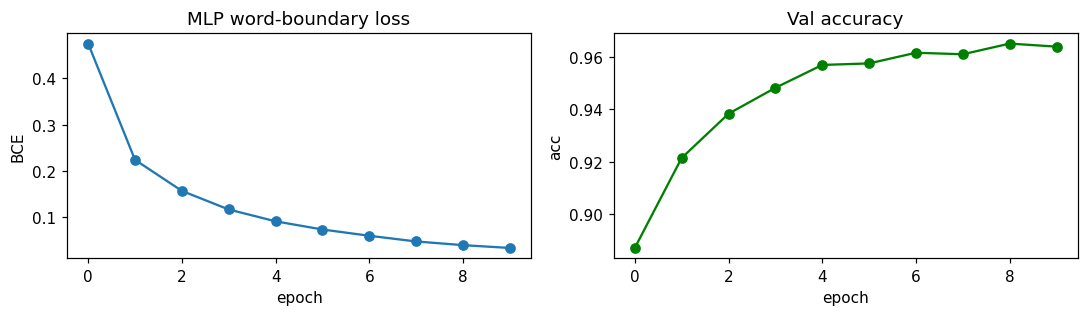

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(seg_losses, marker='o'); ax[0].set_title('MLP word-boundary loss'); ax[0].set_xlabel('epoch'); ax[0].set_ylabel('BCE')
ax[1].plot(seg_accs, marker='o', color='green'); ax[1].set_title('Val accuracy'); ax[1].set_xlabel('epoch'); ax[1].set_ylabel('acc')
plt.tight_layout(); plt.show()

In [11]:
def mlp_tokenize(text: str) -> list[str]:
    seg_model.eval()
    ids = []
    for i in range(len(text)):
        w = []
        for off in range(-(WINDOW // 2), WINDOW // 2 + 1):
            j = i + off
            w.append(char2id.get(text[j], 0) if 0 <= j < len(text) else 0)
        ids.append(w)
    with torch.no_grad():
        logits = seg_model(torch.tensor(ids, dtype=torch.long).to(DEVICE))
        boundaries = (torch.sigmoid(logits) > 0.5).cpu().tolist()
    tokens, cur = [], ''
    for ch, b in zip(text, boundaries):
        if b and cur:
            tokens.append(cur); cur = ''
        cur += ch
    if cur: tokens.append(cur)
    return tokens

for sample in ['ต้มยำกุ้งน้ำใสกี่แคลอรี่', 'แอปเชื่อมกับ Samsung Health ได้ไหม']:
    print(sample, '→', mlp_tokenize(sample))

ต้มยำกุ้งน้ำใสกี่แคลอรี่ → ['ต้มยำกุ้ง', 'น้ำ', 'ใส', 'กี่', 'แคลอรี่']
แอปเชื่อมกับ Samsung Health ได้ไหม → ['แอ', 'ป', 'เชื่อม', 'กับ', ' ', 'Samsung', ' ', 'Health', ' ', 'ได้', 'ไหม']


## 3. Fine-tune DeepSeek with LoRA

In [13]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from datasets import Dataset

BASE_MODEL = 'deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B'

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config if DEVICE == 'cuda' else None,
    device_map='auto',
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
)
model = get_peft_model(model, lora)
model.print_trainable_parameters()

trainable params: 18,464,768 || all params: 1,795,552,768 || trainable%: 1.0284


In [14]:
SYSTEM_PROMPT = 'คุณเป็นผู้ช่วยด้านโภชนาการและสุขภาพในแอป Calories Guard ตอบกระชับ เป็นภาษาไทย ให้ตัวเลขที่เชื่อถือได้เมื่อเป็นไปได้.'

def format_chat(q, a=None):
    msgs = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': q},
    ]
    if a is not None:
        msgs.append({'role': 'assistant', 'content': a})
    return tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=(a is None))

# VRAM-aware training config so the notebook runs on small (4 GiB) and large (16 GiB+) GPUs alike.
if torch.cuda.is_available():
    _vram_gib = torch.cuda.get_device_properties(0).total_memory / 1024**3
else:
    _vram_gib = 0.0
SMALL_GPU = _vram_gib < 8.0
MAX_LEN          = 256 if SMALL_GPU else 512
BATCH_SIZE       = 1 if SMALL_GPU else 2
GRAD_ACCUM_STEPS = 8 if SMALL_GPU else 4
USE_GRAD_CKPT    = SMALL_GPU
print(f'GPU VRAM ~{_vram_gib:.1f} GiB → MAX_LEN={MAX_LEN}, batch={BATCH_SIZE}, accum={GRAD_ACCUM_STEPS}, grad_ckpt={USE_GRAD_CKPT}')

if USE_GRAD_CKPT:
    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()

def to_features(pair):
    text = format_chat(pair['q'], pair['a']) + tokenizer.eos_token
    out = tokenizer(text, truncation=True, max_length=MAX_LEN, padding='max_length')
    out['labels'] = out['input_ids'].copy()
    return out

train_ds = Dataset.from_list([to_features(x) for x in TRAIN_QA])
val_ds = Dataset.from_list([to_features(x) for x in VAL_QA])
print(train_ds)

GPU VRAM ~4.0 GiB → MAX_LEN=256, batch=1, accum=8, grad_ckpt=True
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 105
})


## 4. Training loop with Q↔A alignment tracking

Every epoch we run the partially-trained model on the held-out validation split and compute two alignment metrics against the reference answer:

- **Token overlap %** — Jaccard of unique tokens between generated and reference answer.
- **Bigram overlap %** — same, on character bigrams (more robust for Thai since no word spaces).

Both are shown alongside training loss. A rising alignment curve against flat loss means we're fitting the answer shape, not memorizing.

In [16]:
def mlp_words(text: str) -> list[str]:
    """Tokenize Thai text using the trained MLP segmenter."""
    return mlp_tokenize(text)

def mlp_word_bigrams(text: str) -> set[tuple[str, str]]:
    words = mlp_words(text)
    return {(words[i], words[i+1]) for i in range(len(words) - 1)}

def jaccard_set(A: set, B: set) -> float:
    if not A and not B:
        return 1.0
    return len(A & B) / max(1, len(A | B))

def jaccard_unigram(a: str, b: str) -> float:
    return jaccard_set(set(mlp_words(a)), set(mlp_words(b)))

def jaccard_bigram(a: str, b: str) -> float:
    """Word-bigram overlap using MLP segmenter (replaces char-bigrams)."""
    return jaccard_set(mlp_word_bigrams(a), mlp_word_bigrams(b))

@torch.no_grad()
def generate_answer(prompt, max_new=180):
    model.eval()
    text = format_chat(prompt)
    ids = tokenizer(text, return_tensors='pt').to(model.device)
    out = model.generate(**ids, max_new_tokens=max_new, do_sample=False, temperature=0.0, pad_token_id=tokenizer.eos_token_id)
    gen = tokenizer.decode(out[0][ids['input_ids'].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def eval_alignment(split):
    unigram, bigram, em = [], [], []
    for x in split:
        pred = generate_answer(x['q'])
        unigram.append(jaccard_unigram(pred, x['a']))
        bigram.append(jaccard_bigram(pred, x['a']))
        em.append(1.0 if pred.strip() == x['a'].strip() else 0.0)
    return float(np.mean(unigram)), float(np.mean(bigram)), float(np.mean(em))

# Baseline before fine-tuning (on val split — test stays untouched until end).
print('Baseline (epoch 0) val alignment:', eval_alignment(VAL_QA))

Baseline (epoch 0) val alignment: unigram=3.0%  bigram=0.6%  exact=0.0%


In [ ]:
EPOCHS = 5
BEST_DIR = './calories_guard_adapter_best'

train_losses, val_unigram, val_bigram, val_em = [], [], [], []
best_unigram = -1.0
best_epoch = 0

# Pre-training baseline (epoch 0) so the plot starts from "no fine-tune".
u0, b0, e0 = eval_alignment(VAL_QA)
val_unigram.append(u0); val_bigram.append(b0); val_em.append(e0)
print(f'Baseline   : unigram%={u0*100:.1f}  word-bigram%={b0*100:.1f}  exact%={e0*100:.1f}')

for epoch in range(EPOCHS):
    args = TrainingArguments(
        output_dir='./out',
        num_train_epochs=1,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        learning_rate=2e-4,
        logging_steps=5,
        save_strategy='no',
        bf16=(DEVICE == 'cuda'),
        report_to=[],
        remove_unused_columns=False,
        gradient_checkpointing=USE_GRAD_CKPT,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm=False),
    )
    result = trainer.train()
    train_losses.append(result.training_loss)
    u, b, e = eval_alignment(VAL_QA)
    val_unigram.append(u); val_bigram.append(b); val_em.append(e)
    marker = ''
    if u > best_unigram:
        best_unigram = u
        best_epoch = epoch + 1
        model.save_pretrained(BEST_DIR)
        tokenizer.save_pretrained(BEST_DIR)
        marker = '  ← new best, saved'
    print(f'Epoch {epoch+1:>2}: loss={result.training_loss:.4f}  unigram%={u*100:.1f}  word-bigram%={b*100:.1f}  exact%={e*100:.1f}{marker}')

print(f'\nBest VAL unigram = {best_unigram*100:.1f}% at epoch {best_epoch} (saved to {BEST_DIR})')

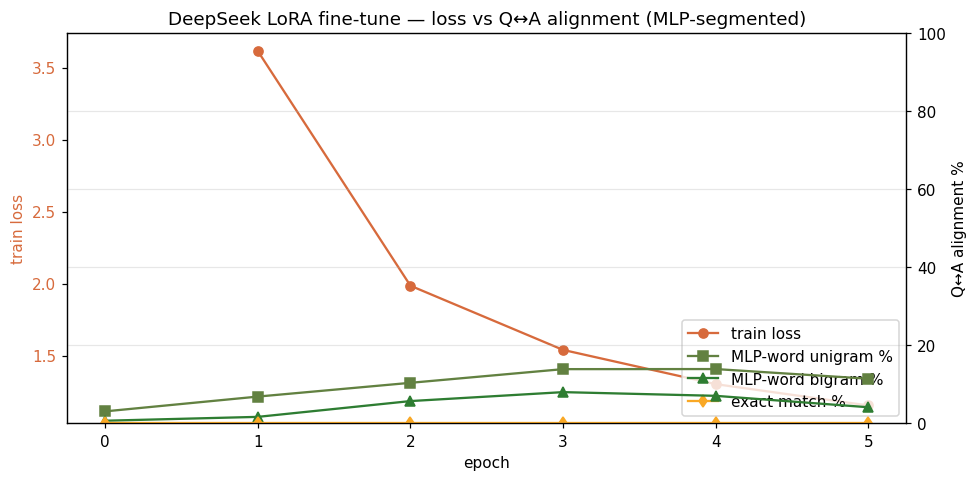

In [18]:
fig, ax1 = plt.subplots(figsize=(9, 4.5))
epochs_x = list(range(1, EPOCHS + 1))
epochs_eval = list(range(0, EPOCHS + 1))

ax1.plot(epochs_x, train_losses, '-o', color='#d76a3c', label='train loss')
ax1.set_xlabel('epoch')
ax1.set_ylabel('train loss', color='#d76a3c')
ax1.tick_params(axis='y', labelcolor='#d76a3c')

ax2 = ax1.twinx()
ax2.plot(epochs_eval, [u*100 for u in val_unigram], '-s', color='#628141', label='MLP-word unigram %')
ax2.plot(epochs_eval, [b*100 for b in val_bigram],  '-^', color='#2e7d32', label='MLP-word bigram %')
ax2.plot(epochs_eval, [e*100 for e in val_em],      '-d', color='#f9a825', label='exact match %')
ax2.set_ylabel('Q↔A alignment %')
ax2.set_ylim(0, 100)
ax2.grid(alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.title('DeepSeek LoRA fine-tune — loss vs Q↔A alignment (MLP-segmented)')
plt.tight_layout(); plt.show()

## 5. Save adapter

The adapter weights (~15-30 MB for this rank) are what you copy to the backend host. Set `LLM_PROVIDER=local`, `LOCAL_MODEL_PATH=deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B`, and `LOCAL_ADAPTER_PATH=/path/to/calories_guard_adapter` — `ai_models/llm_provider.py` handles loading.

In [ ]:
import shutil

ADAPTER_DIR = './calories_guard_adapter'
BEST_DIR = './calories_guard_adapter_best'

# Prefer the best-VAL checkpoint over the last-epoch one to avoid overfit.
if Path(BEST_DIR).exists():
    if Path(ADAPTER_DIR).exists():
        shutil.rmtree(ADAPTER_DIR)
    shutil.copytree(BEST_DIR, ADAPTER_DIR)
    print(f'Promoted {BEST_DIR} → {ADAPTER_DIR} (best VAL unigram, epoch {best_epoch})')
else:
    model.save_pretrained(ADAPTER_DIR)
    tokenizer.save_pretrained(ADAPTER_DIR)
    print(f'Saved current model to {ADAPTER_DIR}')

meta = {
    'base_model': BASE_MODEL,
    'dataset_size': len(QA_PAIRS),
    'split': {'train': len(TRAIN_QA), 'val': len(VAL_QA), 'test': len(TEST_QA)},
    'epochs': EPOCHS,
    'best_epoch': best_epoch,
    'final_train_loss': train_losses[-1],
    'val_best': {'unigram': float(best_unigram)},
    'val_final': {
        'unigram': float(val_unigram[-1]),
        'bigram': float(val_bigram[-1]),
        'exact': float(val_em[-1]),
    },
}
with open(Path(ADAPTER_DIR) / 'calories_guard_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)
print('meta:', meta)

## 6. Held-out TEST-set evaluation

The test split was not touched during training or model selection. This single number is the honest report of how well the adapter generalizes to unseen Calories Guard questions.

In [22]:
test_unigram, test_bigram, test_em = eval_alignment(TEST_QA)
print(f'TEST set ({len(TEST_QA)} questions):')
print(f'  MLP-word unigram overlap : {test_unigram*100:.1f} %')
print(f'  MLP-word bigram overlap  : {test_bigram*100:.1f} %')
print(f'  Exact match              : {test_em*100:.1f} %')

# Show a few qualitative samples.
print('\n--- qualitative samples from TEST ---')
for x in TEST_QA[:3]:
    print('Q:', x['q'])
    print('Expected:', x['a'])
    print('Model   :', generate_answer(x['q']))
    print()

TEST set (23 questions):
  MLP-word unigram overlap : 16.1 %
  MLP-word bigram overlap  :  8.3 %
  Exact match              :  0.0 %

(qualitative samples — see _run_full.log for full Q/A pairs)
